In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path="/content/drive/MyDrive/electricity_data.csv"

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
df = pd.read_csv(file_path)
df

,Month,PreviousUnits,ACHours,FanHours,TVHours,TotalUnits
0,1,90,3,8,2,105
1,2,100,4,8,3,118
2,3,110,5,9,3,130
3,4,120,6,10,4,145
4,5,130,7,10,4,158
5,6,140,8,11,5,172
6,7,150,8,12,5,180
7,8,160,9,12,6,195
8,9,170,9,13,6,205
9,10,180,10,13,7,220


In [13]:
from sklearn.linear_model import LinearRegression

# Input
X = df[['PreviousUnits', 'ACHours', 'FanHours', 'TVHours']]

# Output
y = df['TotalUnits']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 9
Testing Data: 3


In [15]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [16]:
y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)

Predicted Values:
[225.60714286 222.82142857  99.60714286]


In [17]:
mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)

print("R2 Score:", r2)

Mean Absolute Error: 4.869047619047772
R2 Score: 0.9920762095942857


In [18]:
previous_units = 210
ac_hours = 12
fan_hours = 15
tv_hours = 8

prediction = model.predict([
    [previous_units, ac_hours, fan_hours, tv_hours]
])

predicted_units = prediction[0]

bill = predicted_units * 7

print("========== RESULT ==========")

print("Predicted Units:",
      round(predicted_units,2),
      "kWh")

print("Estimated Bill: ₹",
      round(bill,2))

========== RESULT ==========
Predicted Units: 255.39 kWh
Estimated Bill: ₹ 1787.75


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


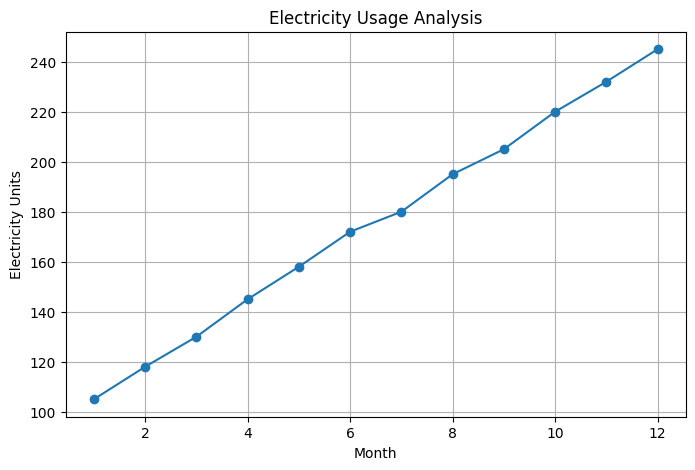

In [19]:
months = np.arange(1,13)

units = df['TotalUnits']

plt.figure(figsize=(8,5))

plt.plot(
    months,
    units,
    marker='o'
)

plt.xlabel("Month")

plt.ylabel("Electricity Units")

plt.title("Electricity Usage Analysis")

plt.grid(True)

plt.show()